# Specific Exploration of FOV3 (S1)
- Load the fov3_strip.parquet
- Per strip gene sparsity check for candidate gene pairs (need >50 per strip for reliable ripley K)
- Confirmation of middle strip infection
- Pick first gene pair and scatter plot for visualisation


## Sanity checks

In [15]:
import pandas as pd
import numpy as np
fov3 = pd.read_parquet("../data/processed/fov3_strips.parquet")

# Basic shape and strip counts
print(f"Total transcripts: {fov3.shape[0]:,}")
print(f"Columns ({len(fov3.columns)}): {list(fov3.columns)}\n")
print(f"Transcripts per strip:\n{fov3['strip'].value_counts().sort_index().to_dict()}")

# Make sure global coordinate columns are present (no output if they are)
assert 'x_global_px' in fov3.columns and 'y_global_px' in fov3.columns, \
    "Global coordinate columns missing — check column names"

# Confirm no NaN coordinates (would silently corrupt KDTree queries later)
n_null = fov3[['x_global_px', 'y_global_px']].isnull().sum().sum()
print(f"\nNull coordinate values: {n_null}")  # must be 0

# Confirm gene column name
print(f"\nGene column sample: {fov3['target'].unique()[:5]}")
print(f"Unique genes: {fov3['target'].nunique()}")


Total transcripts: 72,701
Columns (15): ['x', 'y', 'target', 'cell_ID', 'z_raw', 'cell', 'x_global_px', 'fov', 'y_global_px', 'CellComp', 'y_global_px_transformed', 'x_global_px_transformed', 'strip', 'strip_confidence', 'strip_ambiguous']

Transcripts per strip:
{'strip_1': 37870, 'strip_2': 18283, 'strip_3': 16548}

Null coordinate values: 0

Gene column sample: ['INS', 'PPIA', 'CXCL17', 'MALAT1', 'TYROBP']
Categories (1206, object): ['AATK', 'ABL1', 'ABL2', 'ACACB', ..., 'SystemControl29', 'SystemControl11', 'SystemControl64', 'SystemControl67']
Unique genes: 1123


## Checking gene sparsity per strip

In [20]:
# Pivot: rows = genes, columns = strips, values = transcript count
strip_counts = (
    fov3.groupby(['target', 'strip'], observed=False) # false means dont drop cells with 0 observations
    .size()
    .unstack(fill_value=0)  # genes absent from a strip get 0, not NaN
)

print(f"Gene x Strip matrix shape: {strip_counts.shape}")

Gene x Strip matrix shape: (1206, 3)


**New matrix now that represents 1206 genes and 3 strips**


## Determining all genes with minimum required gene counts

In [26]:
MIN_TRANSCRIPTS = 50  # minimum per strip — justified by point pattern literature

# A gene is 'usable' in a strip if it has >= MIN_TRANSCRIPTS there
usable = strip_counts >= MIN_TRANSCRIPTS

print(f"Genes meeting threshold per strip:\n {usable.sum().to_dict()}")

# Genes usable in ALL three strips — these are your most comparable candidates
usable_all = strip_counts[(usable['strip_1']) & (usable['strip_2']) & (usable['strip_3'])]
print(f"\nGenes usable in all 3 strips ({len(usable_all)}):\n {usable_all.sort_values('strip_2',ascending=False).head(20)}")

Genes meeting threshold per strip:
 {'strip_1': 86, 'strip_2': 24, 'strip_3': 17}

Genes usable in all 3 strips (16):
 strip     strip_1  strip_2  strip_3
target                             
MALAT1       3801     1920     1524
NEAT1        1665      449      549
PPIA          670      349      290
RPL21         521      230      253
SCGB3A1       224      200       82
HMGN2         318      132      134
KRT18         231      118      103
RPL34         217      106       95
TPT1          204      105       53
RPL32         187       91       88
MHC I         237       90      100
RPL22         140       83       70
KRT8          158       74       70
RPL37         132       72       50
KRT19         176       64       87
EIF5A/L1       93       52       50


**FOV 3 strip_1 contains two physically separate tissue fragments captured in a single GMM component. Strip_3 is the cleaner single-strip control. For all pairwise comparisons in this FOV, primary contrast is strip_2 (infected) vs strip_3 (control). Strip_1 retained for secondary comparison but its composite nature noted as a caveat**

## Confirmation of Strip 2 Infection

In [31]:
# Genes usable in both strip_2 and strip_3 
usable_s2_s3 = strip_counts[
    (strip_counts['strip_2'] >= MIN_TRANSCRIPTS) &
    (strip_counts['strip_3'] >= MIN_TRANSCRIPTS)
].sort_values('strip_2',ascending=False)

print(f"Genes usable in strip_2 and strip_3 ({len(usable_s2_s3)}):\n {usable_s2_s3[['strip_2', 'strip_3']]}")


Genes usable in strip_2 and strip_3 (16):
 strip     strip_2  strip_3
target                    
MALAT1       1920     1524
NEAT1         449      549
PPIA          349      290
RPL21         230      253
SCGB3A1       200       82
HMGN2         132      134
KRT18         118      103
RPL34         106       95
TPT1          105       53
RPL32          91       88
MHC I          90      100
RPL22          83       70
KRT8           74       70
RPL37          72       50
KRT19          64       87
EIF5A/L1       52       50


(MALAT1, NEAT1, PPIA, RPL21, RPL34, RPL32, RPL22, RPL37, EIF5A/L1, HMGN2, TPT1) are all housekeeping genes - uninformative due to broad expression.

That leaves these:
- KRT18, KRT8, KRT19 - epithelial keratins, co-expressed in the same cell type
- SCGB3A1 - airway secretory epithelial marker
- MHC I - immune/antigen-presenting cells


KRT18 and KRT8 are obligate heterodimer partners - they form intermediate filaments together in simple epithelial cells and are essentially always co-expressed. This makes them a useful positive control pair: if the K-function implementation is correct, these two genes must show strong co-localisation because their transcripts originate from the same cells. If we don't detect co-localisation for KRT8/KRT18, the implementation is broken. If we do, we have biological validation of the method.
    - (Overexpressed in many cancers)

KRT8: 74 transcripts in strip_2
KRT18: 118 transcripts in strip_2


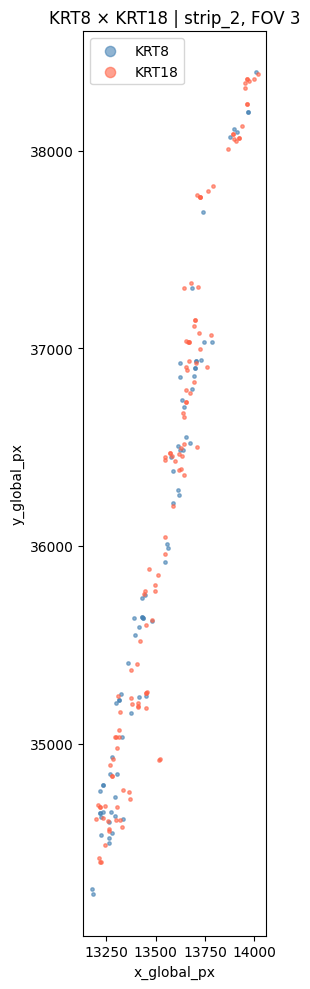

In [43]:
# Are KRT8 and KRT18 transcripts visually interleaved, or just in the same blob?
# Scatter plot is a sanity check

import matplotlib.pyplot as plt

GENE_A = 'KRT8'
GENE_B = 'KRT18'
STRIP  = 'strip_2'

strip_df = fov3[fov3['strip'] == STRIP]
coords_a = strip_df[strip_df['target'] == GENE_A][['x_global_px', 'y_global_px']].values
coords_b = strip_df[strip_df['target'] == GENE_B][['x_global_px', 'y_global_px']].values

print(f"{GENE_A}: {len(coords_a)} transcripts in {STRIP}")
print(f"{GENE_B}: {len(coords_b)} transcripts in {STRIP}")

fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(coords_a[:, 0], coords_a[:, 1], s=6, alpha=0.6, color='steelblue', label=GENE_A)
ax.scatter(coords_b[:, 0], coords_b[:, 1], s=6, alpha=0.6, color='tomato', label=GENE_B)
ax.set_xlabel("x_global_px")
ax.set_ylabel("y_global_px")
ax.set_title(f"{GENE_A} × {GENE_B} | {STRIP}, FOV 3")
ax.legend(markerscale=3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

Clear co-localisation just form the visual - what we would expect given that these genes come from the same cell types.

The elongated nature of these tissues is potentially an issue given that edge correction will be a part of the analysis. Those points closest to the left and right will me more heavily affected than those near the top/bottom boundary. Width of ~900 pixels here means r values of > ~400 will almsot certainly extend far outside of the narrow dimensions. 

r_max of 300 should keep these effects to a minimum. 